In [8]:
import pandas as pd
df=pd.read_csv("house_prices.csv")
print(df.head())

   area  bedrooms  bathrooms  age  location_score    price
0   650         1          1   20               4  1850000
1   720         2          1   15               5  2150000
2   800         2          1   18               6  2400000
3   850         2          2   10               6  2650000
4   900         2          2   12               7  2900000


In [9]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   area            10 non-null     int64
 1   bedrooms        10 non-null     int64
 2   bathrooms       10 non-null     int64
 3   age             10 non-null     int64
 4   location_score  10 non-null     int64
 5   price           10 non-null     int64
dtypes: int64(6)
memory usage: 608.0 bytes
None
              area   bedrooms  bathrooms       age  location_score  \
count    10.000000  10.000000  10.000000  10.00000       10.000000   
mean    917.000000   2.400000   1.800000  10.70000        6.400000   
std     163.981706   0.699206   0.632456   5.47824        1.264911   
min     650.000000   1.000000   1.000000   4.00000        4.000000   
25%     812.500000   2.000000   1.250000   6.50000        6.000000   
50%     925.000000   2.500000   2.000000   9.50000        6.500000   
75%    1037.50000

In [10]:
df.dropna()
df.fillna(df.mean())
df.fillna(method='ffill')

,area,bedrooms,bathrooms,age,location_score,price
0,650,1,1,20,4,1850000
1,720,2,1,15,5,2150000
2,800,2,1,18,6,2400000
3,850,2,2,10,6,2650000
4,900,2,2,12,7,2900000
5,950,3,2,8,6,3100000
6,1000,3,2,9,7,3350000
7,1050,3,2,5,8,3650000
8,1100,3,2,6,7,3750000
9,1150,3,3,4,8,4050000


In [13]:
x=df[["area","bedrooms","bathrooms","age","location_score"]]
y=df["price"]
print(x.shape)
print(y.shape)

(10, 5)
(10,)


In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Train size:",x_train.shape[0])
print("Test size:",x_test.shape[0])

Train size: 8
Test size: 2


In [16]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print("Coefficients:",model.coef_)
print("Intercept:",model.intercept_)

Coefficients: [   6319.21487603 -244576.44628099 -232024.79338843  -19989.66942149
  -74018.59504132]
Intercept: -1100103.3057851251


In [17]:
y_pred=model.predict(x_test)
print(y_pred[:5])
print(y_test.values[:5])

[4015185.95041322 2058615.70247934]
[3750000 2150000]


In [19]:
from sklearn.metrics import(
mean_absolute_error,mean_squared_error,r2_score)
import numpy as np
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE:",mae,"MSE:",mse,"RMSE:",rmse,"R2:",r2)

MAE: 178285.12396694184 MSE: 39337339064.9544 RMSE: 198336.42899113212 R2: 0.9385354077110087


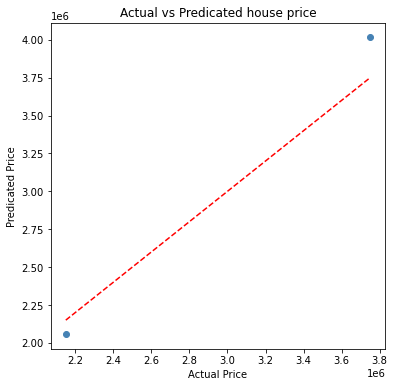

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred,color="Steelblue")
plt.plot([y_test.min(),y_test.max()],
        [y_test.min(),y_test.max()],"r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicated Price")
plt.title("Actual vs Predicated house price")
plt.show()

In [23]:
x2=df[["area","bedrooms","location_score"]]
y2=df["price"]
x2_train,x2_test,y2_train,y2_test=train_test_split(
x2,y2,test_size=0.2,random_state=42)
model2=LinearRegression()
model2.fit(x2_train,y2_train)
pred2=model2.predict(x2_test)
print("R2(3 features):",r2_score(y2_test,pred2))
print("R2(5 features):",r2)

R2(3 features): 0.9875589386969577
R2(5 features): 0.9385354077110087
